In [1]:
import random
import matplotlib.pyplot as plt
import math
from scipy.stats import multinomial
import collections

In [2]:
def p_confuse(i_utt, p_utt, certain_zero, certain_it):
    if i_utt == 'it':
        if p_utt == 'it':
            return certain_it
        elif p_utt == 'zero':
            return 1 - certain_it
        else:
            return 0
    elif i_utt == 'zero':
        if p_utt == 'zero':
            return certain_zero
        elif p_utt == 'it':
            return 1 - certain_zero
        else:
            return 0
    elif i_utt == p_utt:
        return 1
    else:
        return 0

In [3]:
certain_zero = 0.9
certain_it = 0.4

In [4]:
p_confuse('zero', 'it', certain_zero, certain_it)

0.09999999999999998

In [5]:
states = ['agent_falls', 'patient_falls']

In [6]:
utterances = ['agent', 'patient', 'it', 'zero']

In [7]:
meaning = {'zero': {'agent_falls'}, 'it': {'agent_falls', 'patient_falls'}, 'agent': {'agent_falls'}, 'patient': {'patient_falls'}}

In [8]:
meaning['patient']

{'patient_falls'}

In [9]:
def state_prior(state):
    if state == 'agent_falls':
        return 0.32
    else:
        return 0.68

In [10]:
def p_meaning(utt, state):
    if state in meaning[utt]:
        return 1
    else:
        return 0

In [11]:
def literal_listener(p_utt, certain_zero, certain_it):
    probs = []
    
    for state in states:
        p = state_prior(state) * sum(p_confuse(i_utt, p_utt, certain_zero, certain_it) * p_meaning(i_utt, state) for i_utt in utterances)
        probs.append(p)

    return {states[i]: probs[i] / sum(probs) for i in range(len(states))}

In [12]:
literal_listener('zero', 1, 0.7)

{'agent_falls': 0.6709677419354838, 'patient_falls': 0.32903225806451614}

In [13]:
def speaker(state, alpha, certain_zero, certain_it):
    # speaker that cumulatively reasons about all possible perceived utterances
    probs = []
    
    for i_utt in utterances:
        pl = sum(p_confuse(i_utt, p_utt, certain_zero, certain_it) * literal_listener(p_utt, certain_zero, certain_it)[state] for p_utt in utterances)

        if pl == 0:
            p = 0
        else:
            p = math.exp(alpha * math.log(pl))
            
        probs.append(p)

    return {utterances[i]: probs[i] / sum(probs) for i in range(len(utterances))}

In [14]:
def speaker2(state, alpha, certain_zero, certain_it):
    # speaker that every time tries one possible perceived utterance
    probs = []
    
    for i_utt in utterances:
        p = 0

        for p_utt in utterances:
            pl = literal_listener(p_utt, certain_zero, certain_it)[state]
    
            if pl > 0:
                p += p_confuse(i_utt, p_utt, certain_zero, certain_it) * math.exp(alpha * math.log(pl))
            
        probs.append(p)

    return {utterances[i]: probs[i] / sum(probs) for i in range(len(utterances))}

In [15]:
speaker('agent_falls', 2, 1, 0.7)

{'agent': 0.613094633658846,
 'patient': 0.0,
 'it': 0.11089156581444955,
 'zero': 0.27601380052670454}

In [16]:
speaker2('agent_falls', 2, 1, 0.7)

{'agent': 0.6035232392997654,
 'patient': 0.0,
 'it': 0.12477198000236736,
 'zero': 0.27170478069786724}

In [17]:
def pragmatic_listener(p_utt, alpha, certain_zero, certain_it):
    probs = []
    
    for state in states:
        p = state_prior(state) * sum(p_confuse(i_utt, p_utt, certain_zero, certain_it) * speaker(state, alpha, certain_zero, certain_it)[i_utt] for i_utt in utterances)
        probs.append(p)

    return {states[i]: probs[i] / sum(probs) for i in range(len(states))}

In [18]:
pragmatic_listener('zero', 2, 1, 0.7)

{'agent_falls': 0.5024277709416015, 'patient_falls': 0.49757222905839854}

In [22]:
def dist_all(*params):
    d = {}
    
    for value in params[1]:
        d[value] = params[0](value, *params[2:])

    return d

In [23]:
dist_all(literal_listener, utterances, 1, 1)

{'agent': {'agent_falls': 1.0, 'patient_falls': 0.0},
 'patient': {'agent_falls': 0.0, 'patient_falls': 1.0},
 'it': {'agent_falls': 0.1, 'patient_falls': 0.9},
 'zero': {'agent_falls': 1.0, 'patient_falls': 0.0}}

In [24]:
dist_all(speaker, states, 1, 1, 1)

{'agent_falls': {'agent': 0.47619047619047616,
  'patient': 0.0,
  'it': 0.04761904761904762,
  'zero': 0.47619047619047616},
 'patient_falls': {'agent': 0.0,
  'patient': 0.5263157894736842,
  'it': 0.4736842105263158,
  'zero': 0.0}}

In [25]:
def plot(dist):
    layers = list(list(dist.values())[0].keys())

    layer_values = []
    bottom = [0 for bar in dist]
    
    for layer in layers:
        values = []
        
        for bar in dist:
            value = dist[bar][layer] if layer in dist[bar] else 0
            values.append(value)

        layer_values.append(values)

    for i in range(len(layer_values)):
        c = plt.bar(dist.keys(), layer_values[i], bottom = bottom)
        plt.bar_label(c, label_type = 'center')

        for j in range(len(bottom)):
            bottom[j] += layer_values[i][j]

    plt.legend(layers)

In [26]:
def plot_literal_listener(*params):
    plot(dist_all(literal_listener, utterances, *params))

In [27]:
def plot_speaker(*params):
    plot(dist_all(speaker, states, *params))

In [28]:
def plot_pragmatic_listener(*params):
    plot(dist_all(pragmatic_listener, utterances, *params))

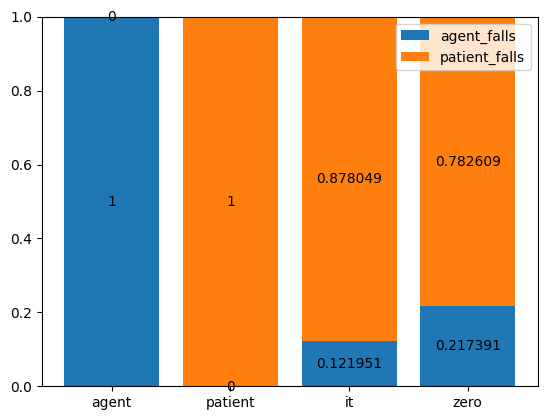

In [29]:
plot_literal_listener(0.9, 0.4)

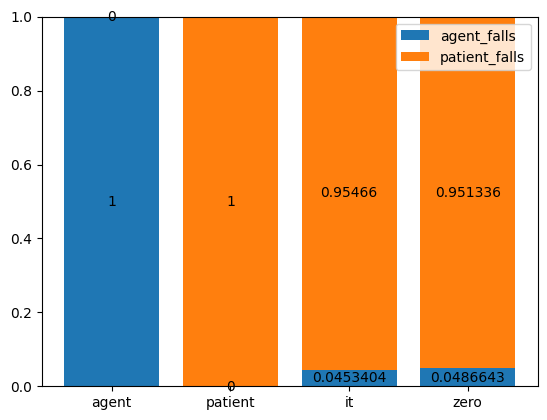

In [30]:
plot_pragmatic_listener(1, 0.9, 0.4)

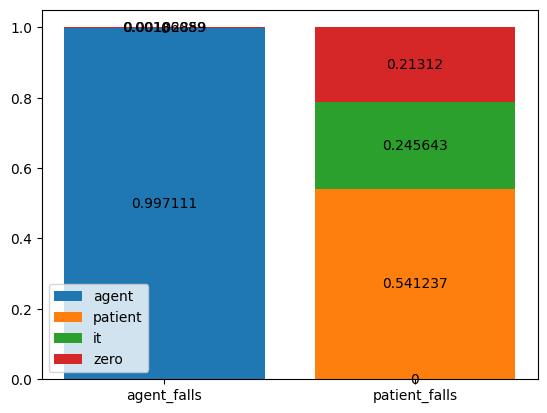

In [31]:
plot_speaker(4, 0.9, 0.4)

In [32]:
speaker_data = {'agent_falls': [256, 0, 56, 976], 'patient_falls': [0, 366, 24, 7]}

In [33]:
def sample(n, function, *params):
    dist = function(*params)
    ct = collections.Counter({key: 0 for key in dist.keys()})
    ct.update(random.choices(list(dist.keys()), weights = dist.values(), k = n))
    return [ct[key] for key in dist]

In [34]:
sample(1000, speaker, 'patient_falls', 1, 1, 1)

[0, 563, 437, 0]

In [35]:
def check_data(data, function, *params):
    n = sum(data)
    d = multinomial(n, [ct/n for ct in data])
    s = sample(n, function, *params)
    return d.pmf(s)

In [36]:
check_data(speaker_data['patient_falls'], speaker, 'patient_falls', 1, 1, 1)

6.387996561894307e-131

In [37]:
def estimate_speaker(speaker_data, iterations = 10000):
    samples = []
    
    for i in range(iterations):
        alpha = random.uniform(0, 10)
        certain_it = random.uniform(0, 1)
        certain_zero = random.uniform(0, 1)
    
        for state in states:
            p = check_data(speaker_data[state], speaker, state, alpha, certain_zero, certain_it)
            samples.append((p, alpha, certain_zero, certain_it))

    means = [0, 0, 0]

    for sample in samples:
        for i in range(len(means)):
            means[i] += sample[0]*sample[i+1]

    total_p = sum(sample[0] for sample in samples)

    return [mean/total_p for mean in means]

In [38]:
estimate_speaker(speaker_data)

[9.79721840556641, 0.062085666270544626, 0.31410178169930236]

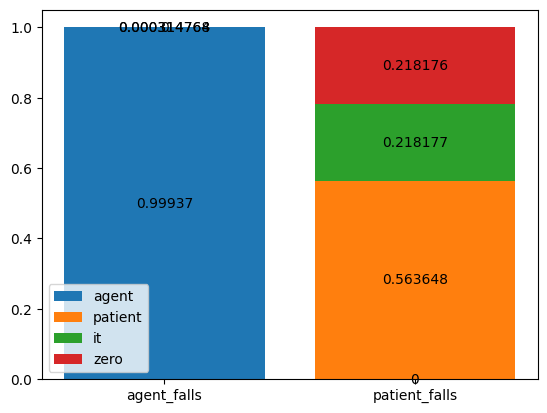

In [39]:
plot_speaker(4.729763903951333, 0.4756020856607506, 0.5230868381492905)